# 03 — Model Evaluation & Offer Strategy

This notebook provides:
1. **Cross-validation diagnostics** — residual analysis, calibration, error by segment
2. **Geographic analysis** — which zip codes are "hot" (under-priced vs. model) and which carry premium
3. **Feature importance** — what drives price in the filtered model
4. **"Highest & Best" offer framework** — translates model output into an actionable bid range

All metrics below are computed on **cross-validated predictions** (each observation
predicted by a model that never trained on it) to avoid optimistic bias.

In [1]:
# ---------------------------------------------------------------------------
# Imports & load artefacts
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import joblib
import os
import warnings
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SEED = 51
np.random.seed(SEED)

os.makedirs("plots", exist_ok=True)

# Load model artefacts
filt_artefact = joblib.load("models/hedonic_model_filtered.joblib")
model_f       = filt_artefact["model"]
feat_cols_f   = filt_artefact["feature_cols"]
resid_std_f   = filt_artefact["residual_std"]
monthly_appr  = filt_artefact.get("monthly_appreciation", 0)

full_artefact = joblib.load("models/hedonic_model.joblib")

# Load results (contain CV predictions)
res_f = pd.read_csv("data/model_results_filtered.csv")
res   = pd.read_csv("data/model_results.csv")

# Use CV predictions for unbiased error analysis
if "cv_predicted" in res_f.columns:
    res_f["pred_eval"]  = res_f["cv_predicted"]
    res_f["resid_eval"] = res_f["PRICE"] - res_f["cv_predicted"]
else:
    res_f["pred_eval"]  = res_f["predicted"]
    res_f["resid_eval"] = res_f["residual"]

# ── Zip → city lookup (built from training data) ──────────────────────────────
if "CITY" in res_f.columns:
    zip_city = (
        res_f.dropna(subset=["zip", "CITY"])
        .groupby("zip")["CITY"]
        .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else "")
        .to_dict()
    )
else:
    zip_city = {}

def zlabel(z):
    """Return 'XXXXX – City' label for a zip code."""
    city = zip_city.get(str(z), "")
    return f"{z} – {city}" if city else str(z)

print(f"Filtered results: {len(res_f):,} rows")
print(f"Full results:     {len(res):,} rows")
print(f"Residual σ:       ${resid_std_f:,.0f}")
print(f"Monthly trend:    ${monthly_appr:,.0f}/mo")

Filtered results: 6,345 rows
Full results:     23,448 rows
Residual σ:       $88,512
Monthly trend:    $-151/mo


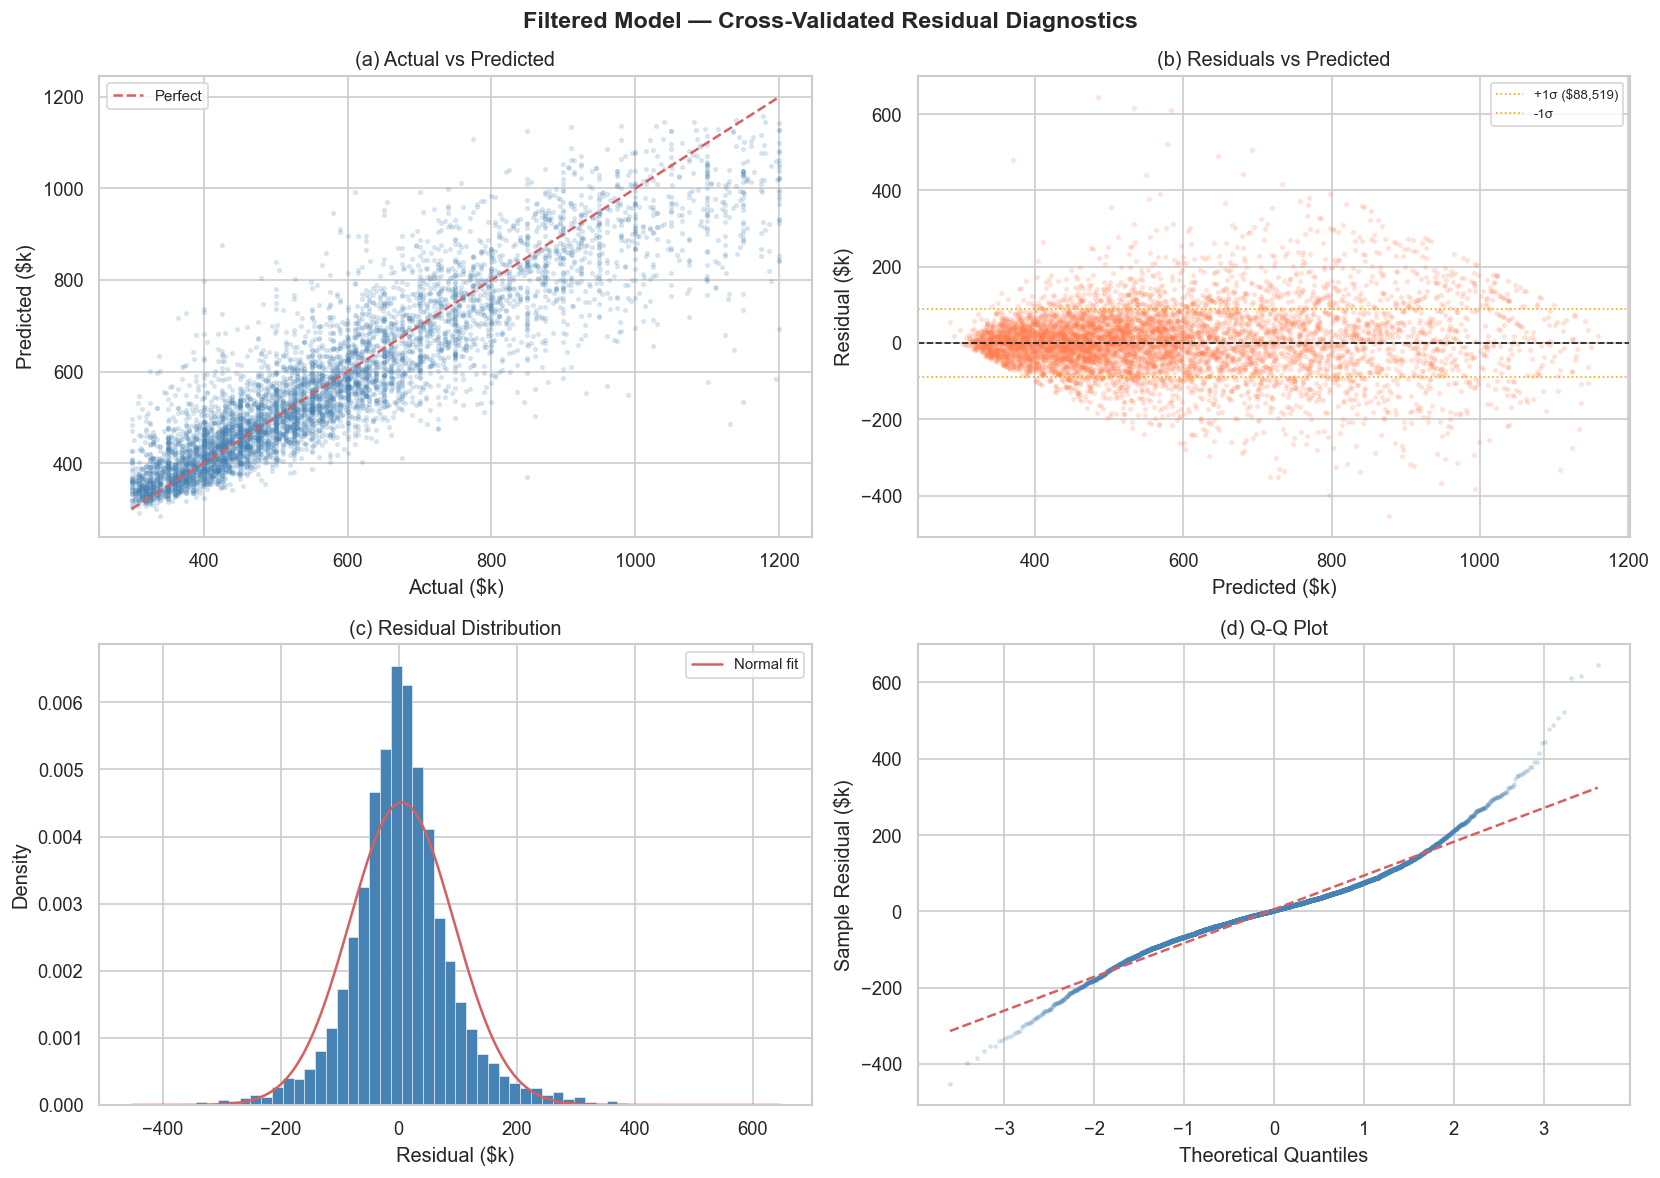

Residual skewness:  0.470  (0 = symmetric)
Residual kurtosis:  3.770  (0 = normal)
Shapiro-Wilk p:     0.0000  (non-normal)

Note: mild non-normality in tails is typical for housing data.
Prediction intervals below use the empirical residual distribution, not a normal assumption.


In [2]:
# ---------------------------------------------------------------------------
# 1. Residual diagnostics — filtered model (CV-based)
# ---------------------------------------------------------------------------
resid = res_f["resid_eval"]
pred  = res_f["pred_eval"]
actual = res_f["PRICE"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Filtered Model — Cross-Validated Residual Diagnostics",
             fontsize=14, fontweight="bold")

# (a) Actual vs Predicted
ax = axes[0, 0]
ax.scatter(actual / 1e3, pred / 1e3, alpha=0.15, s=5, c="steelblue")
lims = [actual.min() / 1e3, actual.max() / 1e3]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
ax.set_xlabel("Actual ($k)")
ax.set_ylabel("Predicted ($k)")
ax.set_title("(a) Actual vs Predicted")
ax.legend(fontsize=9)

# (b) Residuals vs Predicted (check heteroscedasticity)
ax = axes[0, 1]
ax.scatter(pred / 1e3, resid / 1e3, alpha=0.15, s=5, c="coral")
ax.axhline(0, c="k", ls="--", lw=1)
ax.axhline( resid.std() / 1e3, c="orange", ls=":", lw=1, label=f"+1σ (${resid.std():,.0f})")
ax.axhline(-resid.std() / 1e3, c="orange", ls=":", lw=1, label="-1σ")
ax.set_xlabel("Predicted ($k)")
ax.set_ylabel("Residual ($k)")
ax.set_title("(b) Residuals vs Predicted")
ax.legend(fontsize=8)

# (c) Residual histogram + normality
ax = axes[1, 0]
ax.hist(resid / 1e3, bins=60, color="steelblue", edgecolor="white", lw=0.3, density=True)
xr = np.linspace(resid.min(), resid.max(), 200) / 1e3
ax.plot(xr, stats.norm.pdf(xr, resid.mean()/1e3, resid.std()/1e3),
        "r-", lw=1.5, label="Normal fit")
ax.set_xlabel("Residual ($k)")
ax.set_ylabel("Density")
ax.set_title("(c) Residual Distribution")
ax.legend(fontsize=9)

# (d) QQ plot
ax = axes[1, 1]
sorted_resid = np.sort(resid)
n = len(sorted_resid)
theoretical_q = stats.norm.ppf(np.arange(1, n+1) / (n+1))
ax.scatter(theoretical_q, sorted_resid / 1e3, alpha=0.15, s=4, c="steelblue")
ql, qh = theoretical_q[[0, -1]]
ax.plot([ql, qh], [ql * resid.std()/1e3 + resid.mean()/1e3,
                    qh * resid.std()/1e3 + resid.mean()/1e3],
        "r--", lw=1.5)
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Residual ($k)")
ax.set_title("(d) Q-Q Plot")

plt.tight_layout()
plt.savefig("plots/residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Normality test
_, shapiro_p = stats.shapiro(resid.sample(min(5000, len(resid)), random_state=SEED))
skew = resid.skew()
kurt = resid.kurtosis()
print(f"Residual skewness:  {skew:.3f}  (0 = symmetric)")
print(f"Residual kurtosis:  {kurt:.3f}  (0 = normal)")
print(f"Shapiro-Wilk p:     {shapiro_p:.4f}  ({'~ normal' if shapiro_p > 0.05 else 'non-normal'})")
print(f"\nNote: mild non-normality in tails is typical for housing data.")
print(f"Prediction intervals below use the empirical residual distribution, not a normal assumption.")

In [3]:
# ---------------------------------------------------------------------------
# 2. Error breakdown by segment — interactive Plotly
# ---------------------------------------------------------------------------
res_f["abs_error"] = res_f["resid_eval"].abs()
zip_stats = (
    res_f.groupby("zip")
    .agg(
        n=("PRICE", "size"),
        median_price=("PRICE", "median"),
        mae=("abs_error", "mean"),
        median_error_pct=("pct_error", "median"),
    )
    .query("n >= 10")
    .sort_values("mae")
    .reset_index()
)
zip_stats["label"] = zip_stats["zip"].apply(zlabel)

top15 = zip_stats.head(15)
bot15 = zip_stats.tail(15).sort_values("mae", ascending=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Best-Predicted Zip Codes", "Hardest-to-Predict Zip Codes"],
    horizontal_spacing=0.15,
)

for trace_df, col, color in [(top15, 1, "#2ecc71"), (bot15, 2, "#e74c3c")]:
    fig.add_trace(
        go.Bar(
            y=trace_df["label"],
            x=trace_df["mae"] / 1e3,
            orientation="h",
            marker_color=color,
            opacity=0.85,
            customdata=np.column_stack([
                trace_df["zip"],
                trace_df["label"],
                trace_df["n"].astype(int),
                (trace_df["median_price"] / 1e3).round(0),
                (trace_df["mae"] / 1e3).round(1),
                trace_df["median_error_pct"].round(1),
            ]),
            hovertemplate=(
                "<b>%{customdata[1]}</b><br>"
                "Sales: %{customdata[2]}<br>"
                "Median Sale Price: $%{customdata[3]:.0f}k<br>"
                "Mean Abs Error: $%{customdata[4]:.1f}k<br>"
                "Median % Error: %{customdata[5]:+.1f}%<br>"
                "<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1, col=col,
    )

fig.update_xaxes(title_text="MAE ($k)", row=1, col=1)
fig.update_xaxes(title_text="MAE ($k)", row=1, col=2)
fig.update_layout(
    title="Model Accuracy by Zip Code (≥10 sales) — hover for details",
    height=520, template="plotly_white",
    margin=dict(l=160, r=20, t=70, b=40),
)
fig.show()

# By price band
bins = list(range(300_000, 775_000, 50_000))
labels = [f"${b//1000}k–${(b+50000)//1000}k" for b in bins[:-1]]
res_f["price_band"] = pd.cut(res_f["PRICE"], bins=bins, labels=labels)
band_mae = res_f.groupby("price_band", observed=True)["abs_error"].mean() / 1e3
band_n   = res_f.groupby("price_band", observed=True)["abs_error"].count()

fig2 = go.Figure(go.Bar(
    x=list(band_mae.index.astype(str)),
    y=band_mae.values,
    marker_color="#3498db",
    opacity=0.85,
    customdata=np.column_stack([band_mae.values.round(1), band_n.values]),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "MAE: $%{customdata[0]:.1f}k<br>"
        "Sales: %{customdata[1]}<br>"
        "<extra></extra>"
    ),
))
fig2.update_layout(
    title="MAE by Price Band — Filtered Model",
    xaxis_title="Price Band", yaxis_title="MAE ($k)",
    height=360, template="plotly_white",
)
fig2.show()

In [4]:
# ---------------------------------------------------------------------------
# 3. Geographic analysis — "hot" vs "cool" zips — interactive Plotly
# ---------------------------------------------------------------------------
geo = (
    res_f.groupby("zip")
    .agg(
        n=("PRICE", "size"),
        median_price=("PRICE", "median"),
        median_residual=("resid_eval", "median"),
        mean_residual=("resid_eval", "mean"),
    )
    .query("n >= 10")
    .reset_index()
)
geo["hot_score"] = geo["median_residual"] / resid_std_f
geo["label"]     = geo["zip"].apply(zlabel)
geo_sorted = geo.sort_values("hot_score", ascending=False).reset_index(drop=True)

colors = [
    "#e74c3c" if s > 0.3 else "#27ae60" if s < -0.3 else "#bdc3c7"
    for s in geo_sorted["hot_score"]
]

fig = go.Figure(go.Bar(
    x=geo_sorted.index,
    y=geo_sorted["hot_score"],
    marker_color=colors,
    opacity=0.85,
    customdata=np.column_stack([
        geo_sorted["zip"],
        geo_sorted["label"],
        geo_sorted["n"].astype(int),
        (geo_sorted["median_price"] / 1e3).round(0),
        (geo_sorted["median_residual"] / 1e3).round(1),
        geo_sorted["hot_score"].round(2),
    ]),
    hovertemplate=(
        "<b>%{customdata[1]}</b><br>"
        "Sales: %{customdata[2]}<br>"
        "Median Sale Price: $%{customdata[3]:.0f}k<br>"
        "Median vs Model: $%{customdata[4]:+.0f}k<br>"
        "Hot Score: %{customdata[5]:+.2f}σ<br>"
        "<extra></extra>"
    ),
))

fig.add_hline(y=0.3,  line_dash="dot", line_color="#e74c3c", opacity=0.5,
              annotation_text="Hot threshold (+0.3σ)", annotation_position="top right")
fig.add_hline(y=-0.3, line_dash="dot", line_color="#27ae60", opacity=0.5,
              annotation_text="Cool threshold (−0.3σ)", annotation_position="bottom right")
fig.add_hline(y=0,    line_dash="dash", line_color="black", line_width=1)

fig.update_layout(
    title=(
        "Zip Code 'Hotness' — Median Sale Price vs Model Prediction<br>"
        "<sup>Red = homes sell ABOVE model (competitive market) | "
        "Green = homes sell BELOW model (negotiation room)</sup>"
    ),
    xaxis_title="Zip codes (ranked hottest → coolest)",
    yaxis_title="Residual / σ  (positive = hot)",
    height=480, template="plotly_white",
    showlegend=False,
)
fig.show()

# ── Text summary ─────────────────────────────────────────────────────────────
hot  = geo_sorted[geo_sorted["hot_score"] >  0.3]
cool = geo_sorted[geo_sorted["hot_score"] < -0.3]

print(f"\n🔥 HOT ZIPS — homes sell ABOVE model ({len(hot)} zips)")
for _, r in hot.head(8).iterrows():
    print(f"   {r['label']:<30}  median ${r['median_price']:>9,.0f}  "
          f"above model by ${r['median_residual']:>+7,.0f}  ({r['hot_score']:>+.2f}σ)  n={int(r['n'])}")

print(f"\n❄️  COOL ZIPS — homes sell BELOW model ({len(cool)} zips)")
for _, r in cool.sort_values("hot_score").head(8).iterrows():
    print(f"   {r['label']:<30}  median ${r['median_price']:>9,.0f}  "
          f"below model by ${r['median_residual']:>+7,.0f}  ({r['hot_score']:>+.2f}σ)  n={int(r['n'])}")


🔥 HOT ZIPS — homes sell ABOVE model (6 zips)
   19004                           median $  845,000  above model by $+38,022  (+0.43σ)  n=39
   19003                           median $  630,000  above model by $+37,012  (+0.42σ)  n=26
   19317                           median $  797,500  above model by $+33,080  (+0.37σ)  n=34
   19085                           median $  950,000  above model by $+32,048  (+0.36σ)  n=11
   19066                           median $  965,000  above model by $+30,403  (+0.34σ)  n=18
   19072                           median $  915,500  above model by $+27,999  (+0.32σ)  n=32

❄️  COOL ZIPS — homes sell BELOW model (2 zips)
   19504                           median $  439,950  below model by $-66,337  (-0.75σ)  n=10
   18915                           median $  455,000  below model by $-64,487  (-0.73σ)  n=10


In [5]:
# ---------------------------------------------------------------------------
# 4. Spatial residuals — interactive Plotly mapbox
# ---------------------------------------------------------------------------
if "LATITUDE" in res_f.columns and "LONGITUDE" in res_f.columns:
    plot_df = res_f.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()
    plot_df["resid_clipped"] = plot_df["resid_eval"].clip(-80_000, 80_000)
    cv_col = "cv_predicted" if "cv_predicted" in plot_df.columns else "predicted"

    hover_text = plot_df.apply(
        lambda r: (
            f"<b>{r.get('ADDRESS', '')}</b><br>"
            f"{r.get('CITY', '')} {r.get('zip', '')}<br>"
            f"Sold: ${r['PRICE']:,.0f}<br>"
            f"Model: ${r[cv_col]:,.0f}<br>"
            f"Residual: ${r['resid_eval']:+,.0f}"
        ), axis=1
    )

    fig = go.Figure(go.Scattermapbox(
        lat=plot_df["LATITUDE"],
        lon=plot_df["LONGITUDE"],
        mode="markers",
        marker=dict(
            size=7,
            opacity=0.7,
            color=plot_df["resid_clipped"] / 1e3,
            colorscale="RdYlGn",
            cmin=-80, cmax=80,
            showscale=True,
            colorbar=dict(
                title="Residual<br>($k)",
                tickformat="$,.0f",
                thickness=14,
            ),
        ),
        text=hover_text,
        hoverinfo="text",
    ))
    fig.update_layout(
        mapbox_style="open-street-map",
        mapbox=dict(center=dict(lat=39.98, lon=-75.38), zoom=9.8),
        title=(
            "Spatial Residuals — Green = sold BELOW model (potential value), "
            "Red = sold ABOVE model (hot / premium area)"
        ),
        height=620,
        margin=dict(t=50, b=0, l=0, r=0),
    )
    fig.show()
else:
    print("No LATITUDE / LONGITUDE columns — skipping spatial plot.")

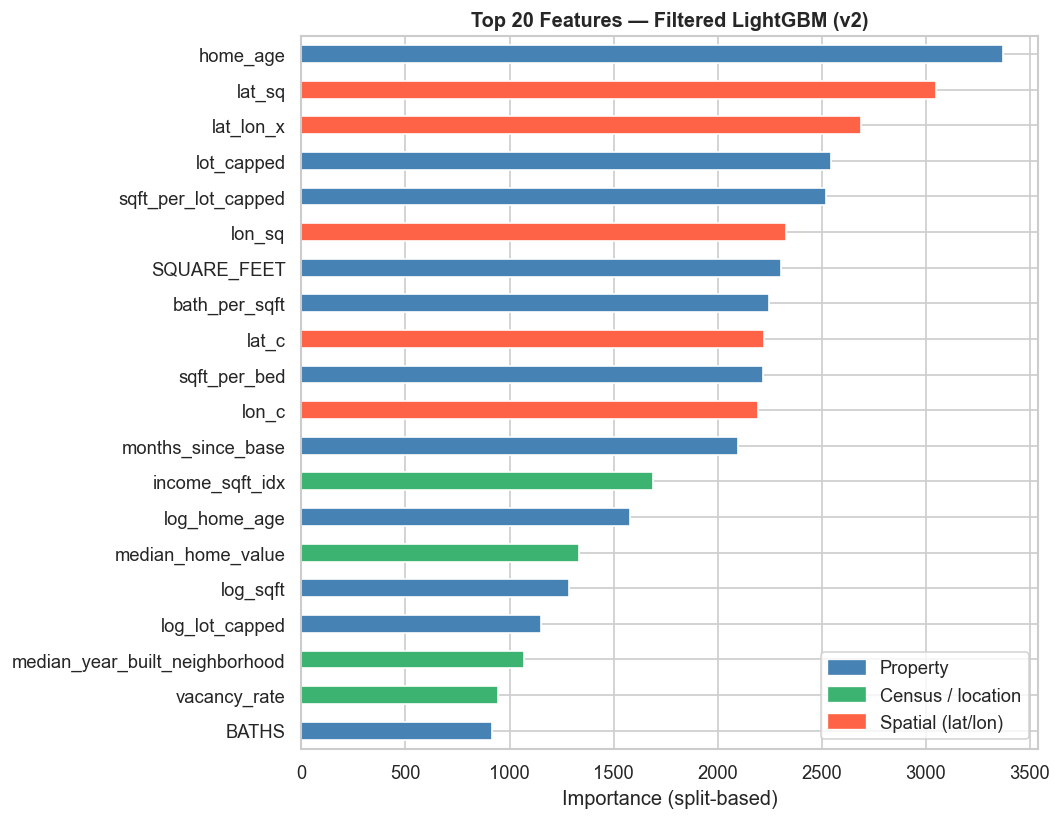


Key v2 additions in top features:
  lon_c                            rank #27  imp=2193
  lat_c                            rank #29  imp=2225
  bath_per_sqft                    rank #30  imp=2248
  lon_sq                           rank #32  imp=2328
  lat_lon_x                        rank #35  imp=2691
  lat_sq                           rank #36  imp=3052


In [6]:
# ---------------------------------------------------------------------------
# 5. Feature importance — filtered model (v2)
# ---------------------------------------------------------------------------
# v2 feature groups for colour-coding the importance chart
SPATIAL_SET = {"lat_c","lon_c","lat_sq","lon_sq","lat_lon_x"}
CENSUS_SET  = {
    "median_household_income","median_home_value","median_gross_rent",
    "population","median_year_built_neighborhood","mean_commute_time",
    "vacancy_rate","pct_bachelors_plus","poverty_rate","homeownership_rate",
    "income_sqft_idx","wealth_edu_idx","commute_sq",
}

if hasattr(model_f, "feature_importances_"):
    importances = model_f.feature_importances_
    feat_imp = pd.Series(importances, index=feat_cols_f).sort_values()
    top = feat_imp.tail(20)

    def _feat_color(name):
        if name in SPATIAL_SET:  return "tomato"
        if name in CENSUS_SET:   return "mediumseagreen"
        return "steelblue"

    colors = [_feat_color(n) for n in top.index]

    fig, ax = plt.subplots(figsize=(9, 7))
    top.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
    ax.set_title("Top 20 Features — Filtered LightGBM (v2)", fontweight="bold")
    ax.set_xlabel("Importance (split-based)")
    ax.legend(handles=[
        mpatches.Patch(color="steelblue",      label="Property"),
        mpatches.Patch(color="mediumseagreen", label="Census / location"),
        mpatches.Patch(color="tomato",         label="Spatial (lat/lon)"),
    ], loc="lower right")
    plt.tight_layout()
    plt.savefig("plots/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nKey v2 additions in top features:")
    new_feats = {"lat_c","lon_c","lat_sq","lon_sq","lat_lon_x",
                 "BEDS_clean","beds_sq","sin_month","cos_month","is_spring",
                 "wealth_edu_idx","bath_per_sqft","age_historic_x","commute_sq"}
    in_top = [f for f in feat_imp.tail(20).index if f in new_feats]
    for f in in_top:
        print(f"  {f:<32} rank #{list(feat_imp.index).index(f)+1}  imp={feat_imp[f]:.0f}")
else:
    print("Model does not expose feature_importances_ — skipping importance plot.")

## "Highest & Best" Offer Framework

The model produces a **fair-value point estimate**. For real-world bidding, we need a
**range** that accounts for model uncertainty and market dynamics.

### Methodology

| Component | How computed |
|-----------|-------------|
| **Fair value** | LightGBM hedonic prediction |
| **Prediction interval** | Empirical residual distribution (not normal) at ± various quantiles |
| **Appreciation adjustment** | Linear month-over-month trend estimated from `months_since_base` coefficient |
| **DOM discount** | If days-on-market ≥ 45, seller motivation implies 2–5% discount opportunity |
| **Highest & best offer** | Fair value + 1σ of residual distribution (≈84th percentile of comps) |

The **"highest & best"** recommendation represents the price at which ~84% of
comparable recent sales transacted *below* — i.e., a bid at this level should
win most competitive situations without gross overpayment.

In [7]:
# ---------------------------------------------------------------------------
# 6. predict_fair_value() + offer_range() - production-ready functions (v3)
# ---------------------------------------------------------------------------
import joblib, math, datetime

def predict_fair_value(
    address_zip: str,
    beds: int,
    baths: float,
    sqft: int,
    lot_size: int,
    year_built: int,
    days_on_market: int = None,
    sold_date: str = None,
    property_type: str = 'Single Family Residential',
    county: str = 'Delaware County',
    use_filtered: bool = True,
    census_csv: str = 'data/census_zcta.csv',
    holding_months: int = 60,
):
    model_file = 'models/hedonic_model_filtered.joblib' if use_filtered else 'models/hedonic_model.joblib'
    saved = joblib.load(model_file)
    model        = saved['model']
    quantile_lo  = saved.get('quantile_lo')
    quantile_hi  = saved.get('quantile_hi')
    feature_cols = saved['feature_cols']
    resid_std    = saved['residual_std']
    mo_appr      = saved.get('monthly_appreciation', 0)
    log_target   = saved.get('log_target', False)
    lat_mean_m   = saved.get('lat_mean', 40.0917)
    lon_mean_m   = saved.get('lon_mean', -75.3262)
    lot_99_m     = saved.get('lot_99', 43560.0)
    q_breaks     = saved.get('quintile_breaks', [])
    q_sigma      = saved.get('quintile_sigma', [])

    def seg_sigma(fv):
        if not q_breaks or not q_sigma: return resid_std
        for i, b in enumerate(q_breaks):
            if fv < b: return q_sigma[i]
        return q_sigma[-1]

    # Census lookup
    census_df = pd.read_csv(census_csv)
    census_df['zip'] = census_df['zip'].astype(str).str.zfill(5)
    zip_str   = str(address_zip).zfill(5)[:5]
    zip_match = census_df[census_df['zip'] == zip_str]
    zip_row   = zip_match.iloc[0].to_dict() if not zip_match.empty else census_df.median(numeric_only=True).to_dict()

    CENSUS_FEATURES = [
        'median_household_income', 'median_home_value', 'median_gross_rent',
        'population', 'median_year_built_neighborhood', 'mean_commute_time',
        'vacancy_rate', 'pct_bachelors_plus', 'poverty_rate', 'homeownership_rate',
    ]

    BASE_YEAR = 2026
    BASE_DATE = pd.Timestamp('2024-01-01')
    now       = pd.Timestamp(sold_date) if sold_date else pd.Timestamp.today()
    home_age  = now.year - year_built
    month_num = now.month

    # Beds (v2/v3 features)
    beds_clean = float(np.clip(beds, 1, 7))

    # Lot winsorisation
    lot_capped          = min(lot_size, lot_99_m)
    log_lot_capped      = math.log1p(lot_capped)
    sqft_per_lot_capped = sqft / lot_capped if lot_capped > 0 else 0

    # Spatial: zip centroid lookup (built from results data)
    try:
        _res = pd.read_csv('data/model_results_filtered.csv')
        _cen = (_res.dropna(subset=['LATITUDE','LONGITUDE'])
                   .groupby('zip')[['LATITUDE','LONGITUDE']].median())
        lat, lon = _cen.loc[zip_str, ['LATITUDE','LONGITUDE']] if zip_str in _cen.index else (lat_mean_m, lon_mean_m)
    except Exception:
        lat, lon = lat_mean_m, lon_mean_m
    lat_c = lat - lat_mean_m
    lon_c = lon - lon_mean_m

    # Census composites
    inc     = zip_row.get('median_household_income', np.nan)
    edu     = zip_row.get('pct_bachelors_plus', np.nan)
    commute = zip_row.get('mean_commute_time', np.nan)

    row = {
        'BEDS_clean':          float(np.clip(beds, 1, 7)),
        'beds_sq':             float(np.clip(beds, 1, 7)) ** 2,
        'BATHS':               baths,
        'SQUARE_FEET':         sqft,
        'log_sqft':            math.log1p(sqft),
        'lot_capped':          lot_capped,
        'log_lot_capped':      log_lot_capped,
        'sqft_per_lot_capped': sqft_per_lot_capped,
        'home_age':            home_age,
        'log_home_age':        math.log1p(home_age),
        'is_historic':         int(year_built < 1940),
        'age_historic_x':      home_age * int(year_built < 1940),
        'bath_bed_ratio':      baths / beds if beds > 0 else 0,
        'sqft_per_bed':        sqft / beds  if beds > 0 else 0,
        'bath_per_sqft':       baths / sqft if sqft > 0 else 0,
        'months_since_base':   max((now - BASE_DATE).days / 30.44, 0),
        'sin_month':           math.sin(2 * math.pi * month_num / 12),
        'cos_month':           math.cos(2 * math.pi * month_num / 12),
        'is_spring':           int(month_num in (3, 4, 5, 6)),
        'lat_c':               lat_c,
        'lon_c':               lon_c,
        'lat_sq':              lat_c ** 2,
        'lon_sq':              lon_c ** 2,
        'lat_lon_x':           lat_c * lon_c,
        'wealth_edu_idx':      (inc * edu) if (not np.isnan(inc) and not np.isnan(edu)) else np.nan,
        'commute_sq':          commute ** 2 if not np.isnan(commute) else np.nan,
        'income_sqft_idx':     inc / sqft if (sqft > 0 and not np.isnan(inc)) else np.nan,
    }
    for feat in CENSUS_FEATURES:
        row[feat] = zip_row.get(feat, np.nan)

    input_row = {col: 0 for col in feature_cols}
    input_row.update({k: v for k, v in row.items() if k in feature_cols})
    pt_col = f'PROPERTY_TYPE_{property_type}'
    co_col = f'COUNTY_{county}'
    if pt_col in feature_cols: input_row[pt_col] = 1
    if co_col in feature_cols: input_row[co_col] = 1

    input_df   = pd.DataFrame([input_row])[feature_cols]
    raw_pred   = model.predict(input_df)[0]
    fair_value = float(np.exp(raw_pred) if log_target else raw_pred)

    # 80% prediction interval
    if quantile_lo is not None and quantile_hi is not None:
        raw_lo = quantile_lo.predict(input_df)[0]
        raw_hi = quantile_hi.predict(input_df)[0]
        low  = float(np.exp(raw_lo) if log_target else raw_lo)
        high = float(np.exp(raw_hi) if log_target else raw_hi)
    else:
        ss   = seg_sigma(fair_value)
        low  = fair_value - 1.28 * ss
        high = fair_value + 1.28 * ss

    ss           = seg_sigma(fair_value)
    highest_best = fair_value + ss
    future_value = fair_value + mo_appr * holding_months

    dom_discount = 0
    if days_on_market is not None and days_on_market >= 45:
        pct = min(0.05, 0.02 + (days_on_market - 45) / 1000)
        dom_discount = fair_value * pct

    result = {
        'fair_value':       round(fair_value),
        'low':              round(low),
        'high':             round(high),
        'highest_best':     round(highest_best),
        'dom_discount':     round(dom_discount),
        'future_value_5yr': round(future_value),
        'annual_appr_pct':  round(mo_appr * 12 / fair_value * 100, 2),
    }

    city_name = zip_city.get(zip_str, '')
    zip_display = f'{zip_str} - {city_name}' if city_name else zip_str
    price_max_m = saved.get('price_max', 750_000)
    extrap_warn = '  *** EXTRAPOLATION: near training ceiling ***' if fair_value > price_max_m * 0.90 else ''

    print(f'\n{"=" * 60}')
    print(f'FAIR VALUE & OFFER RANGE')
    print(f'{"=" * 60}')
    print(f'  Zip:         {zip_display}')
    print(f'  Specs:       {beds}bd / {baths}ba / {sqft:,} sqft / {lot_size:,} lot')
    print(f'  Built:       {year_built}  (age {home_age})')
    print(f'  Model:       v{saved.get("feature_version","?")}')
    print(f'')
    print(f'  Fair Value:           ${fair_value:>12,.0f}{extrap_warn}')
    print(f'  80% Prediction Range: ${low:>12,.0f}  -  ${high:>12,.0f}')
    print(f'  Highest & Best Offer: ${highest_best:>12,.0f}  (fair + segment sigma=${ss:,.0f})')
    if dom_discount > 0:
        print(f'  DOM Discount ({days_on_market}d):   -${dom_discount:>11,.0f}')
        print(f'  Suggested Offer:      ${fair_value - dom_discount:>12,.0f}')
    print(f'')
    print(f'  5yr Projected Value:  ${future_value:>12,.0f}  ({result["annual_appr_pct"]:.1f}% ann.)')
    print(f'{"=" * 60}')

    return result


In [8]:
# ---------------------------------------------------------------------------
# Example: 307 Valley Rd, Havertown 19083
# ---------------------------------------------------------------------------
predict_fair_value(
    address_zip   = "19083",
    beds          = 3,
    baths         = 2,
    sqft          = 2170,
    lot_size      = 10_019,
    year_built    = 1950,
    property_type = "Single Family Residential",
    county        = "Delaware County",
)


FAIR VALUE & OFFER RANGE
  Zip:         19083
  Specs:       3bd / 2ba / 2,170 sqft / 10,019 lot
  Built:       1950  (age 76)
  Model:       v3

  Fair Value:           $     634,408
  80% Prediction Range: $     498,765  -  $     704,410
  Highest & Best Offer: $     738,954  (fair + segment sigma=$104,546)

  5yr Projected Value:  $     625,360  (-0.3% ann.)


{'fair_value': 634408,
 'low': 498765,
 'high': 704410,
 'highest_best': 738954,
 'dom_discount': 0,
 'future_value_5yr': 625360,
 'annual_appr_pct': np.float64(-0.29)}

In [9]:
# ---------------------------------------------------------------------------
# Example: 227 Forrest Ave, Narberth 19072
# ---------------------------------------------------------------------------
predict_fair_value(
    address_zip    = "19072",
    beds           = 5,
    baths          = 1.5,
    sqft           = 1954,
    lot_size       = 4878,
    year_built     = 1925,
    days_on_market = 0,
)


FAIR VALUE & OFFER RANGE
  Zip:         19072
  Specs:       5bd / 1.5ba / 1,954 sqft / 4,878 lot
  Built:       1925  (age 101)
  Model:       v3

  Fair Value:           $     712,578
  80% Prediction Range: $     494,145  -  $     797,018
  Highest & Best Offer: $     817,124  (fair + segment sigma=$104,546)

  5yr Projected Value:  $     703,531  (-0.2% ann.)


{'fair_value': 712578,
 'low': 494145,
 'high': 797018,
 'highest_best': 817124,
 'dom_discount': 0,
 'future_value_5yr': 703531,
 'annual_appr_pct': np.float64(-0.25)}